In [1]:
import time
import random
import math
import matplotlib.pyplot as plt

from solvers import solve_by_gauss, solve_by_svd, solve_by_gauss_seidel

### 1. Thực nghiệm đo thời gian và sai số

**Mô tả thực nghiệm:** Giải hệ $Ax=b$ trên ma trận ngẫu nhiên đối xứng xác định dương (SPD) với các kích thước $n \in \{50, 100, 200, 500, 1000\}$. 

**Biểu đồ Log-Log (Bên dưới):** Trục hoành là kích thước $n$ (log scale), trục tung là thời gian thực thi (log scale). Đường nét đứt thể hiện chi phí lý thuyết $O(n^3)$ của phương pháp giải trực tiếp.

In [2]:
def generate_spd_matrix(n):
    A = [[random.uniform(-10, 10) for _ in range(n)] for _ in range(n)]
    for i in range(n):
        for j in range(i + 1, n):
            A[i][j] = A[j][i]  # Ép đối xứng
            
    for i in range(n):
        row_sum = sum(abs(A[i][j]) for j in range(n) if j != i)
        A[i][i] = row_sum + random.uniform(1.0, 5.0)  # Ép chéo trội chặt dương
    return A

def generate_hilbert_matrix(n):
    return [[1.0 / (i + j + 1) for j in range(n)] for i in range(n)]

def generate_vector(n):
    return [random.uniform(-10, 10) for _ in range(n)]

def mat_vec_multiply(A, x):
    n = len(A)
    return [sum(A[i][j] * x[j] for j in range(n)) for i in range(n)]

def l2_norm(v):
    return math.sqrt(sum(vi ** 2 for vi in v))

def compute_relative_error(A, x_hat, b):
    Ax = mat_vec_multiply(A, x_hat)
    residual = [Ax[i] - b[i] for i in range(len(b))]
    norm_residual = l2_norm(residual)
    norm_b = l2_norm(b)
    
    if norm_b < 1e-12:
        return norm_residual
    return norm_residual / norm_b

In [3]:
def run_benchmark():
    sizes = [50, 100, 200, 500] #, 1000]
    methods = {
        "Gauss": solve_by_gauss,
        "SVD": solve_by_svd,
        "Gauss-Seidel": solve_by_gauss_seidel
    }
    
    avg_times = {name: [] for name in methods}
    errors = {name: [] for name in methods}

    for n in sizes:
        
        times_n = {name: [] for name in methods}
        errors_n = {name: [] for name in methods}
        
        # Giảm số lần chạy với các ma trận quá lớn
        num_runs = 5 if n <= 200 else 1 
        
        for run_idx in range(num_runs):
            A = generate_spd_matrix(n)
            b = generate_vector(n)
            
            for name, solver_func in methods.items():
                start_time = time.time()
                try:
                    x_hat = solver_func(A, b)
                    end_time = time.time()
                    elapsed = end_time - start_time
                    
                    times_n[name].append(elapsed)
                    errors_n[name].append(compute_relative_error(A, x_hat, b))
                    print(f"    -> {name} xong trong {elapsed:.4f} giây")
                except Exception as e:
                    print(f"    -> Lỗi ở {name}: {e}")
                    
        for name in methods:
            if times_n[name]:
                avg_times[name].append(sum(times_n[name]) / len(times_n[name]))
                errors[name].append(sum(errors_n[name]) / len(errors_n[name]))
                
    plt.figure(figsize=(10, 6))
    
    for name in methods:
        plt.loglog(sizes, avg_times[name], marker='o', label=f'{name}')
        
    if avg_times["Gauss"]:
        c = avg_times["Gauss"][0] / (sizes[0]**3)
        theoretical_times = [c * (n**3) for n in sizes]
        plt.loglog(sizes, theoretical_times, 'k--', label='Lý thuyết $O(n^3)$')

    plt.title('Đồ thị Log-Log: Thời gian thực thi của các phương pháp giải hệ Ax=b')
    plt.xlabel('Kích thước ma trận n (log scale)')
    plt.ylabel('Thời gian thực thi (giây) (log scale)')
    plt.grid(True, which="both", ls="--")
    plt.legend()
    plt.show()
    
    print("\nSAI SỐ TƯƠNG ĐỐI TRUNG BÌNH (||Ax - b|| / ||b||):")
    for name in methods:
        print(f"Phương pháp {name}:")
        for i, n in enumerate(sizes):
            print(f"  n = {n:<4}: {errors[name][i]:.5e}")

In [4]:
def analyze_stability():
    n = 20
    methods = {"Gauss": solve_by_gauss, "SVD": solve_by_svd}
    
    print("\n1. Với ma trận ngẫu nhiên SPD (Well-conditioned):")
    A_spd = generate_spd_matrix(n)
    b_spd = generate_vector(n)
    for name, func in methods.items():
        x_hat = func(A_spd, b_spd)
        err = compute_relative_error(A_spd, x_hat, b_spd)
        print(f"  - Sai số ({name}): {err:.5e}")
        
    print("\n2. Với ma trận Hilbert (Ill-conditioned):")
    A_hilb = generate_hilbert_matrix(n)
    b_hilb = generate_vector(n)
    for name, func in methods.items():
        try:
            x_hat = func(A_hilb, b_hilb)
            err = compute_relative_error(A_hilb, x_hat, b_hilb)
            print(f"  - Sai số ({name}): {err:.5e}")
        except Exception as e:
            print(f"  - Sai số ({name}): Thất bại ({e})")

    -> Gauss xong trong 0.0029 giây
    -> SVD xong trong 20.9236 giây
    -> Gauss-Seidel xong trong 0.0009 giây
    -> Gauss xong trong 0.0030 giây
    -> SVD xong trong 21.4357 giây
    -> Gauss-Seidel xong trong 0.0009 giây
    -> Gauss xong trong 0.0029 giây
    -> SVD xong trong 21.3152 giây
    -> Gauss-Seidel xong trong 0.0011 giây
    -> Gauss xong trong 0.0029 giây
    -> SVD xong trong 20.9904 giây
    -> Gauss-Seidel xong trong 0.0009 giây
    -> Gauss xong trong 0.0029 giây
    -> SVD xong trong 21.3152 giây
    -> Gauss-Seidel xong trong 0.0009 giây
    -> Gauss xong trong 0.0215 giây
    -> SVD xong trong 175.0104 giây
    -> Gauss-Seidel xong trong 0.0033 giây
    -> Gauss xong trong 0.0208 giây
    -> SVD xong trong 173.0790 giây
    -> Gauss-Seidel xong trong 0.0027 giây
    -> Gauss xong trong 0.0207 giây
    -> SVD xong trong 171.3424 giây
    -> Gauss-Seidel xong trong 0.0033 giây
    -> Gauss xong trong 0.0208 giây
    -> SVD xong trong 172.1158 giây
    -> Gauss-

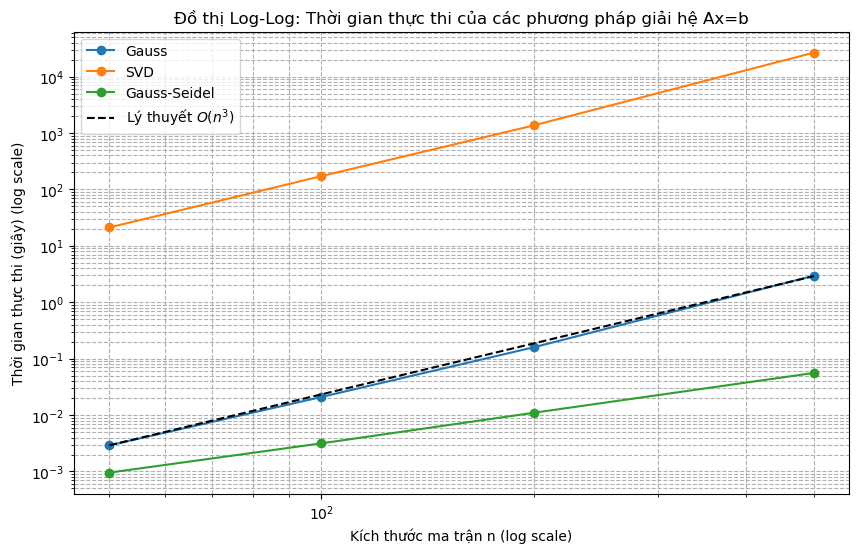


SAI SỐ TƯƠNG ĐỐI TRUNG BÌNH (||Ax - b|| / ||b||):
Phương pháp Gauss:
  n = 50  : 5.39373e-16
  n = 100 : 6.19775e-16
  n = 200 : 9.41811e-16
  n = 500 : 1.48821e-15
Phương pháp SVD:
  n = 50  : 8.96734e-05
  n = 100 : 2.45427e-04
  n = 200 : 5.28407e-04
  n = 500 : 8.07524e-04
Phương pháp Gauss-Seidel:
  n = 50  : 7.34754e-07
  n = 100 : 2.48369e-07
  n = 200 : 1.65272e-07
  n = 500 : 6.67016e-07

1. Với ma trận ngẫu nhiên SPD (Well-conditioned):
  - Sai số (Gauss): 3.33198e-16
  - Sai số (SVD): 4.87145e-14

2. Với ma trận Hilbert (Ill-conditioned):
  - Sai số (Gauss): Thất bại (Inconsistent: row 17 gives 0 = 5.92202)
  - Sai số (SVD): 3.39589e+03


In [5]:
run_benchmark()
analyze_stability()